# 22_因果机器学习-401(k) 综合案例：平均效应与异质性

## Notebook 使用说明

这是因果学习系列的第 18 份，也是“22. 因果机器学习”的第 8 份。建议先阅读《03. 双重机器学习与交互回归模型》《05. DR-Learner与R-Learner》和《07. 因果效应模型的评价与验证》。需要 NumPy、pandas、Matplotlib、SciPy、scikit-learn 和 statsmodels：`python -m pip install numpy pandas matplotlib scipy scikit-learn statsmodels`。

本篇将参考资料 [2] 第 9.3 节的平均效应分析与第 15.2、15.3 节的异质性评价连起来。[1] 第 10–13 章用于对照识别、加权和双重稳健估计。记 $T=\texttt{e401}$ 为资格，$Y=\texttt{net\_tfa}$ 为净金融资产；实际参与变量 `p401` 不作为处理，也不作为主分析的控制变量。

真实数据来自配套仓库的 `data/401k.csv`，原始 9,915 行、44 列，完整 CSV 快照已嵌入并带 SHA-256 与 Git blob 校验。主分析按照配套 `T/datasets.py` 的收入筛选保留 9,716 行，使用其中的 14 个控制变量。[3–4] 资格定义、样本限制和变量口径沿用来源；学习器参数、随机划分和下面的诊断是本篇的 Python 实现，不声称逐数值复现原书表 9.3 或第 15 章图表。

先按 60%／20%／20% 划分训练、选择和最终测试集，完成冻结模型的验证，再做预先指定的全样本平均效应分析。默认 5 折交叉拟合；另在固定开发样本中比较 10 个分折种子，同时区间使用 4,999 次高斯模拟。全部结果均由本文件实际计算，没有真实个人效应标签，也不报告真实 CATE 的 RMSE。运行时不访问网络、不依赖前面笔记的变量或辅助模块。重新运行请使用 Restart Kernel and Run All Cells。

In [1]:
# 环境初始化：完整数据在本文件中；不屏蔽模型拟合或数值警告。
import os
import sys
import tempfile
import base64
import gzip
import hashlib
from io import BytesIO
from pathlib import Path

os.environ.setdefault("MPLCONFIGDIR", str(Path(tempfile.gettempdir()) / "ml_notebooks_matplotlib"))
os.environ.setdefault("OMP_NUM_THREADS", "1")
os.environ.setdefault("OPENBLAS_NUM_THREADS", "1")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import font_manager
from IPython.display import display
import scipy
from scipy.stats import norm, chi2
from scipy.optimize import minimize
import sklearn
from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler, SplineTransformer
from sklearn.linear_model import Ridge, LogisticRegression
from sklearn.ensemble import HistGradientBoostingRegressor, HistGradientBoostingClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import mean_squared_error, brier_score_loss
import statsmodels
import statsmodels.api as sm
from threadpoolctl import threadpool_limits

%matplotlib inline
_available_fonts = {f.name for f in font_manager.fontManager.ttflist}
CJK_FONTS = [f for f in ["Arial Unicode MS", "PingFang SC", "Heiti TC", "Microsoft YaHei",
                        "SimHei", "Noto Sans CJK SC", "Noto Sans CJK JP"]
             if f in _available_fonts] + ["DejaVu Sans"]
plt.rcParams.update({"font.sans-serif": CJK_FONTS, "axes.unicode_minus": False,
                     "figure.dpi": 100, "figure.max_open_warning": 30})
pd.set_option("display.max_columns", 14)
pd.set_option("display.width", 160)
_thread_limit = threadpool_limits(limits=1)

SEED_SPLIT = 2026
SEED_FOLDS = 42
SEED_LEARNER = 99
SEED_BAND = 2030
SEEDS_RESPLIT = tuple(range(2100, 2110))
N_FOLDS = 5
N_GAUSSIAN = 4999
CLIP = 0.01
Q_GRID = np.linspace(0.1, 0.9, 9)
Z_CRIT = norm.ppf(0.975)
MONEY_UNIT = 1000.0  # 模型、图表中的货币单位统一为千美元；不是对数变换。
CONT_COLS = ["age", "inc", "fsize", "educ"]
X_COLS = ["age", "inc", "fsize", "educ", "db", "marr", "male", "twoearn", "pira",
          "nohs", "hs", "smcol", "col", "hown"]
BINARY_COLS = [c for c in X_COLS if c not in CONT_COLS]

print(f"Python {sys.version.split()[0]}")
print(f"NumPy {np.__version__} | pandas {pd.__version__} | Matplotlib {plt.matplotlib.__version__}")
print(f"SciPy {scipy.__version__} | scikit-learn {sklearn.__version__} | statsmodels {statsmodels.__version__}")

Python 3.13.5
NumPy 2.3.5 | pandas 2.2.3 | Matplotlib 3.10.8
SciPy 1.17.0 | scikit-learn 1.8.0 | statsmodels 0.14.6


前面的模拟可以把估计值与真值比较。这次没有真值。一个看起来合理的效应曲线，需要先经过样本、变量和验证流程的检查；换一套学习器得到相近的数值，也不能代替识别假设。

这个案例问的是：在数据覆盖的历史人群中，获得 401(k) 资格是否增加净金融资产，以及这种增加是否随已观测特征而变化。它不是当年的新增储蓄额，也不是给个人提供投资建议。

## 理论基础

### 1. 资格、参与和资产，是三件不同的事

401(k) 是美国雇主提供的退休储蓄安排。本案例使用 1991 年 SIPP 数据，研究对象处于该安排较早的推广时期。[2，第 9.3 节；3]

| 变量 | 含义 | 在本篇中的作用 |
|---|---|---|
| `e401` | 是否具有 401(k) 资格 | 二元处理 $T$ |
| `p401` | 是否实际参与 | 描述资格与参与的关系，不进入主模型 |
| `net_tfa` | 净金融资产，美元 | 结局 $Y$；包括相应金融资产并扣除非住房抵押债务 |
| `age, inc, fsize, educ` | 年龄、收入、家庭人数、教育年限 | 连续或计数型控制变量 |
| `db, marr, male, twoearn, pira, hown` | 养老金、婚姻、男性、双收入、IRA 参与、住房拥有指标 | 按来源保留的二元控制变量 |
| `nohs, hs, smcol, col` | 四类教育指标 | 配套异质性分析额外保留的教育编码 |

原书第 9.3 节列出 10 个原始控制变量；第 15 章配套代码另外保留四个教育指标，合计 14 个。本篇使用后者，不把两套规格视为同一个数值复现。原文件中的其他资产、旧预测 `zhat` 和分类编码，不因“有这一列”就自动加入控制集。[2，第 9.3 节；3–4]

### 2. 因果解释依赖什么？

定义 $Y(t)$ 为资格设为 $t$ 时的净金融资产。在一致性、无干扰、条件可忽略性和重叠条件下，

$$
Y(t)\perp T\mid X,\qquad 0<e(X)=P(T=1\mid X)<1,
$$

$$
\tau(x)=E[Y(1)-Y(0)\mid X=x]=\mu_1(x)-\mu_0(x),\qquad
\mu_t(x)=E[Y\mid T=t,X=x].
$$

原书的历史论证是：早期求职者可能更关注收入等工作条件，而非是否提供 401(k)。在充分调整这些因素后，资格可被视为条件外生。这是需要研究背景支持的论证，不是“数据来自调查，所以外生”。书中也讨论了反例：未观测企业特征、雇主匹配缴费或风险偏好可能留下未关闭的混杂路径。[2，第 7.2、9.3 节]

本篇沿用来源对 `pira`、`hown` 等变量的工作设定。这个截面文件本身不能证明它们都在资格之前测量，也不能证明它们不受资格影响。匹配缴费细节、潜在储蓄偏好和完整纵向历史并未进入这里的控制集。后面的区间是在识别假设成立时解释，不包含这些假设可能失效所带来的误差。

### 3. 一个总体平均数与一条效应函数

令 $S=1$ 表示满足本篇的收入限制。主目标是

$$
\theta_{\mathrm{ATE},S}=E[Y(1)-Y(0)\mid S=1],\qquad
\theta_{\mathrm{ATT},S}=E[Y(1)-Y(0)\mid T=1,S=1].
$$

后面的期望、交叉拟合和模型评价默认都在 $S=1$ 的分析人群中。收入限制只改变纳入的人，不将极端结局改成别的数值。由于 $S$ 是 $X$ 的函数，保留区域内的条件效应定义不变，但平均时的人群分布改变了。[1，第 13、20 章]

给每一行生成折外预测后，ATE 使用

$$
\widehat\Gamma_i=\widehat\mu_{1i}-\widehat\mu_{0i}
+\frac{T_i(Y_i-\widehat\mu_{1i})}{\widehat e_i}
-\frac{(1-T_i)(Y_i-\widehat\mu_{0i})}{1-\widehat e_i},
\qquad \widehat\theta_{\mathrm{ATE}}=\frac1n\sum_i\widehat\Gamma_i.
$$

这里 $\widehat\mu_{ti}$ 与 $\widehat e_i$ 均由没有见过第 $i$ 行结局、处理的训练折产生。标准误取

$$
\widehat{\mathrm{se}}_{\mathrm{ATE}}
=\frac{\sqrt{n^{-1}\sum_i(\widehat\Gamma_i-\widehat\theta_{\mathrm{ATE}})^2}}{\sqrt n}.
$$

这采用原书的经验矩分母 $n$，不是将伪结局当作已知个人效应。交叉拟合、正交得分、辅助模型误差控制和足够重叠共同支持渐近推断；某次软件成功返回结果并不验证这些条件。[1，第 12 章；2，第 9.3–9.4 节]

### 4. 真实数据怎样验证异质性？

固定一个在别处训练好的模型 $f$，在独立样本上计算 DR 损失。比较 $f$ 与训练集常数模型 $c$ 时，逐行差值为

$$
\Delta_i=(\widehat\Gamma_i-f(X_i))^2-(\widehat\Gamma_i-c)^2
=(f(X_i)-c)\{f(X_i)+c-2\widehat\Gamma_i\}.
$$

在辅助信号条件均值正确时，它的期望是两个模型真实函数 MSE 的差，而不是任一模型的绝对 MSE。两个平方共享同一个伪结局，因此应计算逐行配对差的标准误。[2，第 15.2 节]

本篇最终冻结一个 Q-aggregation 组合，用另外的测试集检查四件事：相对常数的损失差；$\widehat\Gamma\sim 1+f(X)$ 的 BLP 斜率；预先固定分组的校准；预先固定优先规则的 uplift。它们分别评价数值误差、线性异质性信号、尺度校准和排序价值，不能互相替代。[2，第 15.3 节]

## 算法流程

读入并核对完整快照 → 按来源确定分析人群 → 划分训练／选择／测试 → 在训练集内交叉拟合 → 训练少量候选 CATE 模型 → 在选择集上组合并冻结 → 用测试集做一次最终验证 → 再报告预先指定的全样本平均效应和稳定性诊断。

全样本 ATE 的目标是平均效应推断，不要求再留出一个预测测试集。但如果提前用全样本结局挑选 CATE 学习器，刚才的测试集便不再独立。因此，本篇把这部分放在冻结和验证之后，且不据此修改前面的模型。

## 完整案例

### 1. 先把样本数对上

配套数据说明给出 9,915 条记录，观测对象为家庭参照人及存在时的配偶，年龄范围 25–64 岁；样本要求家庭中至少一人就业、没有人自雇。[3] 这里沿用书中的独立观测工作模型，文件没有用于本次实现的调查权重、抽样层或企业聚类标识，所以不把普通标准误描述成复杂抽样设计校正的结果。

配套异质性代码使用收入的第 1、99 百分位数：收入为正、不低于下界、严格低于上界。这一步把 9,915 变成 9,716，不是删除缺失值，也不是裁剪净金融资产。[4] 本文件保留完整数据，以便同时核对原书的未调整差值。

In [2]:
# 完整原始 CSV 的压缩快照。展开本单元即可检查，不需要额外数据文件。
DATA_SHA256 = "23b36abdb222471f3ebedab4526cdf78aed3675827eefa96fc3af6e34c47e8e7"
DATA_GIT_BLOB = "cc6fa730232fcceac21a786fe017ad8ecf4d32d8"
DATA_B64 = (
    "..."
)

def load_snapshot(payload=DATA_B64):
    data_bytes = gzip.decompress(base64.b64decode(payload, validate=True))
    if hashlib.sha256(data_bytes).hexdigest() != DATA_SHA256:
        raise ValueError("数据快照 SHA-256 校验失败。")
    git_hash = hashlib.sha1(f"blob {len(data_bytes)}\0".encode()+data_bytes).hexdigest()
    if git_hash != DATA_GIT_BLOB:
        raise ValueError("数据快照与来源 Git blob 不一致。")
    result = pd.read_csv(BytesIO(data_bytes))
    if result.shape != (9915, 44) or not np.isfinite(result.to_numpy(dtype=float)).all():
        raise ValueError("数据维度或数值完整性不符。")
    return result

raw = load_snapshot()
raw.index.name = "原始行号"
income_low, income_high = np.percentile(raw.inc, [1, 99])
mask = (raw.inc > 0) & (raw.inc >= income_low) & (raw.inc < income_high)
analysis = raw.loc[mask, X_COLS].copy()
analysis["T"] = raw.loc[mask, "e401"].astype(int)
analysis["Y"] = raw.loc[mask, "net_tfa"] / MONEY_UNIT
assert len(analysis) == 9716
assert not {"p401", "a401", "net_tfa", "zhat"}.intersection(X_COLS)
assert (raw.p401 <= raw.e401).all()

sample_flow = pd.DataFrame({
    "样本数": [len(raw), int((raw.inc < income_low).sum()), int((raw.inc >= income_high).sum()), len(analysis)],
    "含义": ["完整原始记录", "收入低于第1百分位", "收入不低于第99百分位", "主分析人群"]
})
display(sample_flow)
print(f"收入限制：[{income_low:.2f}, {income_high:.2f}) 美元；同时要求收入为正。")
print(f"缺失单元：{raw.isna().sum().sum()}；完全重复行：{raw.duplicated().sum()}")
print(f"原始负净资产记录：{(raw.net_tfa < 0).sum()}；本篇不据此删除或改写结局。")
display(pd.crosstab(raw.e401, raw.p401).rename_axis(index="资格e401", columns="参与p401"))
print("原始样本未调整均值差（美元）：", round(raw.loc[raw.e401 == 1, "net_tfa"].mean()
                                               - raw.loc[raw.e401 == 0, "net_tfa"].mean(), 3))

,样本数,含义
0,9915,完整原始记录
1,99,收入低于第1百分位
2,100,收入不低于第99百分位
3,9716,主分析人群


收入限制：[4080.00, 119058.24) 美元；同时要求收入为正。
缺失单元：0；完全重复行：0
原始负净资产记录：2902；本篇不据此删除或改写结局。


参与p401,0,1
资格e401,,
0,6233,0
1,1088,2594


原始样本未调整均值差（美元）： 19559.345


原始差值可以对上原书约 19,559 美元的基线，但这不是“真实 ATE”。它尚未控制资格组和无资格组的构成差异。下文多数计算针对收入受限的 9,716 条记录，不能要求其结果与 9,915 人样本的表 9.3 完全相同。[2，表 9.3；3–4]

### 2. 在看测试结果前划分任务

随机打乱后按 60%／20%／20% 划分，不依据结局或显著性挑种子。选择集用于给候选模型评分、学习组合权重和确定分组切点。前面的全文件摘要用于核对数据版本，不用于任何模型选择。最终测试结局不进入拟合、组合权重或切点计算。按收入确定样本界限时使用了全体的收入值，这是来源的样本定义；后面推断针对冻结的收入范围，不额外计入样本分位数界限的估计误差。

下面的结局分布图只展示训练集。采用对称对数坐标是为了同时看见负数、零和长尾，回归的结局仍为未变换的净资产除以 1,000。

,n,资格组,无资格组
用途,,,
训练,5829,2191,3638
选择,1943,711,1232
最终测试,1944,710,1234


,n,均值,中位数,标准差
T,,,,
0,3638,9.635,0.15,44.208
1,2191,27.958,9.04,68.594


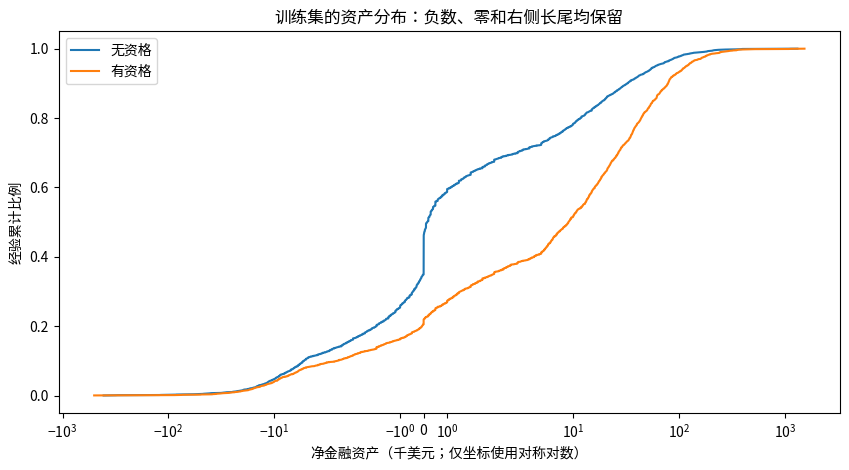

In [3]:
def split_three(n, seed=SEED_SPLIT):
    if not isinstance(n, (int, np.integer)) or n < 30:
        raise ValueError("样本量须为至少 30 的整数。")
    indices = np.random.default_rng(seed).permutation(n)
    n_train, n_score = int(0.6*n), int(0.2*n)
    return indices[:n_train], indices[n_train:n_train+n_score], indices[n_train+n_score:]

split_indices = split_three(len(analysis))
train, score, test = [analysis.iloc[idx].copy() for idx in split_indices]
assert len(set(train.index) & set(score.index)) == 0
assert len(set(train.index) & set(test.index)) == 0
assert len(set(score.index) & set(test.index)) == 0
assert set(train.index) | set(score.index) | set(test.index) == set(analysis.index)

display(pd.DataFrame([
    [name, len(d), int(d["T"].sum()), int((d["T"] == 0).sum())]
    for name, d in [("训练", train), ("选择", score), ("最终测试", test)]
], columns=["用途", "n", "资格组", "无资格组"]).set_index("用途"))
display(train.groupby("T")["Y"].agg(n="size", 均值="mean", 中位数="median", 标准差="std").round(3))

fig, ax = plt.subplots(figsize=(8.6, 4.8))
for t, label in [(0, "无资格"), (1, "有资格")]:
    yy = np.sort(train.loc[train["T"] == t, "Y"])
    ax.plot(yy, np.arange(1, len(yy)+1)/len(yy), label=label)
ax.set_xscale("symlog", linthresh=5)
ax.set(xlabel="净金融资产（千美元；仅坐标使用对称对数）", ylabel="经验累计比例",
       title="训练集的资产分布：负数、零和右侧长尾均保留")
ax.legend()
fig.tight_layout()
plt.show()

### 3. 每一行都有折外的三项预测

主规格使用直方图梯度提升树，分别拟合 $\mu_0$、$\mu_1$ 和 $e$。对照规格使用加性样条加岭回归，以及样条特征上的 Logistic 回归。四个连续变量做样条变换，其余指标原样保留；结点、缩放与回归参数都只在相应训练折上拟合。[5]

本篇不做广泛调参：结果树固定 120 次提升、最多 15 个叶节点、每叶至少 40 人；评分树使用更少的叶节点。参数在运行前给定，不使用测试集挑选。加性样条并不包含所有变量交互，提升树也不保证找到了正确函数。这里比较的是两套工作规格。

先展开训练函数和交叉拟合，再打印折外预测及每折人数。`predict_proba` 给出的才是倾向评分，分类标签不能放进分母。

In [4]:
def vector(x, name="向量"):
    arr = np.asarray(x, dtype=float)
    if arr.ndim != 1 or len(arr) < 2 or not np.isfinite(arr).all():
        raise ValueError(f"{name}须为至少两项的有限一维数组。")
    return arr


def validate_frame(frame):
    if not frame.index.is_unique or not set(X_COLS + ["T", "Y"]).issubset(frame.columns):
        raise ValueError("需要唯一行号与完整的特征、处理和结局。")
    if not np.isfinite(frame[X_COLS + ["T", "Y"]].to_numpy()).all():
        raise ValueError("当前实现不接受缺失或非有限数据。")
    if set(np.unique(frame["T"])) != {0, 1}:
        raise ValueError("处理必须同时包含 0 和 1。")


def spline_features():
    return ColumnTransformer([
        ("连续样条", SplineTransformer(n_knots=4, degree=3, knots="quantile",
                                       include_bias=False, extrapolation="constant"), CONT_COLS),
        ("二元指标", "passthrough", BINARY_COLS)
    ], remainder="drop")


def outcome_model(kind="boost"):
    if kind == "boost":
        return HistGradientBoostingRegressor(max_iter=120, learning_rate=0.05,
                    max_leaf_nodes=15, min_samples_leaf=40, l2_regularization=5,
                    early_stopping=False, random_state=SEED_LEARNER)
    if kind == "spline":
        return make_pipeline(spline_features(), StandardScaler(), Ridge(alpha=20.0))
    raise ValueError("kind 必须为 boost 或 spline。")


def propensity_model(kind="boost"):
    if kind == "boost":
        return HistGradientBoostingClassifier(max_iter=120, learning_rate=0.05,
                    max_leaf_nodes=7, min_samples_leaf=50, l2_regularization=5,
                    early_stopping=False, random_state=SEED_LEARNER)
    if kind == "spline":
        return make_pipeline(spline_features(), StandardScaler(),
                             LogisticRegression(C=1.0, max_iter=2000, tol=1e-8))
    raise ValueError("kind 必须为 boost 或 spline。")


def fit_nuisance(frame, kind="boost"):
    validate_frame(frame)
    fitted = {}
    for t in [0, 1]:
        group = frame["T"] == t
        fitted[f"mu{t}"] = outcome_model(kind).fit(frame.loc[group, X_COLS], frame.loc[group, "Y"])
    fitted["e"] = propensity_model(kind).fit(frame[X_COLS], frame["T"])
    return fitted


def predict_nuisance(fitted, frame, clip=CLIP):
    if not 0 < clip < 0.5:
        raise ValueError("clip 须在 (0,0.5) 内。")
    x = frame[X_COLS]
    p = fitted["e"].predict_proba(x)
    column = list(fitted["e"].classes_).index(1)
    raw_e = p[:, column]
    result = pd.DataFrame({"mu0": fitted["mu0"].predict(x), "mu1": fitted["mu1"].predict(x),
                           "raw_e": raw_e, "e": np.clip(raw_e, clip, 1-clip)}, index=frame.index)
    if not np.isfinite(result.to_numpy()).all():
        raise ArithmeticError("辅助模型产生非有限预测。")
    return result


def crossfit_nuisance(frame, kind="boost", seed=SEED_FOLDS, folds=N_FOLDS, splits=None):
    validate_frame(frame)
    if splits is None:
        if not isinstance(folds, (int, np.integer)) or not 2 <= folds <= frame["T"].value_counts().min():
            raise ValueError("分折数不足或某处理组人数少于分折数。")
        splits = list(StratifiedKFold(n_splits=folds, shuffle=True, random_state=seed).split(frame, frame["T"]))
    output = pd.DataFrame(np.nan, index=frame.index, columns=["mu0", "mu1", "raw_e", "e", "fold"])
    seen = np.zeros(len(frame), dtype=int)
    audit = []
    for k, (fit_idx, out_idx) in enumerate(splits):
        fit_idx, out_idx = np.asarray(fit_idx), np.asarray(out_idx)
        if (len(np.intersect1d(fit_idx, out_idx)) or len(np.unique(fit_idx)) != len(fit_idx)
                or len(np.unique(out_idx)) != len(out_idx)
                or min(fit_idx.min(), out_idx.min()) < 0 or max(fit_idx.max(), out_idx.max()) >= len(frame)):
            raise ValueError("训练与留出索引重复、相交或越界。")
        fitted = fit_nuisance(frame.iloc[fit_idx], kind)
        output.iloc[out_idx, :4] = predict_nuisance(fitted, frame.iloc[out_idx]).to_numpy()
        output.iloc[out_idx, 4] = k
        seen[out_idx] += 1
        tt = frame.iloc[fit_idx]["T"]
        audit.append([k, len(fit_idx), int((tt == 0).sum()), int(tt.sum()), len(out_idx)])
    if not np.all(seen == 1):
        raise ValueError("每行必须且只能作为留出样本一次。")
    return output, pd.DataFrame(audit, columns=["折", "训练n", "训练无资格", "训练有资格", "留出n"]), splits


def dr_signal(frame, eta):
    if not frame.index.equals(eta.index):
        raise ValueError("预测与观察数据行号不一致，不能按位置默默拼接。")
    y, t, e = vector(frame["Y"]), vector(frame["T"]), vector(eta["e"])
    if np.any((e <= 0) | (e >= 1)):
        raise ValueError("计算 DR 信号要求严格位于 (0,1) 的评分。")
    return (eta.mu1.to_numpy()-eta.mu0.to_numpy() + t*(y-eta.mu1.to_numpy())/e
            - (1-t)*(y-eta.mu0.to_numpy())/(1-e))


eta_train, fold_audit, train_splits = crossfit_nuisance(train)
gamma_train = dr_signal(train, eta_train)
display(fold_audit)
row_audit = train[["T", "Y"]].join(eta_train)
row_audit["预测差"] = row_audit.mu1-row_audit.mu0
row_audit["资格侧纠偏"] = row_audit["T"]*(row_audit.Y-row_audit.mu1)/row_audit.e
row_audit["对照侧纠偏"] = (1-row_audit["T"])*(row_audit.Y-row_audit.mu0)/(1-row_audit.e)
row_audit["Gamma"] = gamma_train
display(row_audit.head(8).round(4))

,折,训练n,训练无资格,训练有资格,留出n
0,0,4663,2911,1752,1166
1,1,4663,2910,1753,1166
2,2,4663,2910,1753,1166
3,3,4663,2910,1753,1166
4,4,4664,2911,1753,1165


,T,Y,mu0,mu1,raw_e,e,fold,预测差,资格侧纠偏,对照侧纠偏,Gamma
原始行号,,,,,,,,,,,
8714,1,5.500,15.6439,18.8584,0.3545,0.3545,0.0,3.2145,-37.6808,-0.0000,-34.4663
6445,1,-3.400,-0.5777,4.1019,0.5363,0.5363,1.0,4.6796,-13.9895,-0.0000,-9.3099
4874,0,22.999,39.3430,53.0997,0.3712,0.3712,4.0,13.7567,-0.0000,-25.9928,39.7494
1391,0,10.899,61.8457,82.1216,0.5131,0.5131,1.0,20.2759,-0.0000,-104.6393,124.9152
5909,0,82.250,53.5890,116.7889,0.5387,0.5387,0.0,63.1999,-0.0000,62.1320,1.0679
4388,0,-22.663,0.3122,3.1758,0.3220,0.3220,2.0,2.8636,-0.0000,-33.8864,36.7499
4250,0,-10.430,8.3988,14.7283,0.5641,0.5641,4.0,6.3295,-0.0000,-43.1952,49.5248
3113,0,-7.953,12.4109,23.8809,0.3923,0.3923,2.0,11.4700,-0.0000,-33.5083,44.9783


### 4. 在平均之前，先检查评分和权重

倾向评分预测的是资格，不是“谁会获益”。用 ATE 权重 $T/e+(1-T)/(1-e)$ 检查加权协变量平衡，能帮助发现模型问题；平衡较好仍不能排除未测混杂。

标准化均值差的分母固定为两组未加权方差均值的平方根，调整前后共用同一个分母。有效样本量为 $(\sum_iw_i)^2/\sum_iw_i^2$，分别在两组计算；它反映权重集中程度，不是凭空增加或删除的真实人数。[1，第 11 章]

,训练折外诊断
事实结局RMSE,49.1133
评分Brier,0.1995
最小评分,0.0267
最大评分,0.7504
截断行数,0.0000
ESS_0,3292.0585
最大权重_0,4.0060
ESS_1,1346.6829
最大权重_1,34.4793


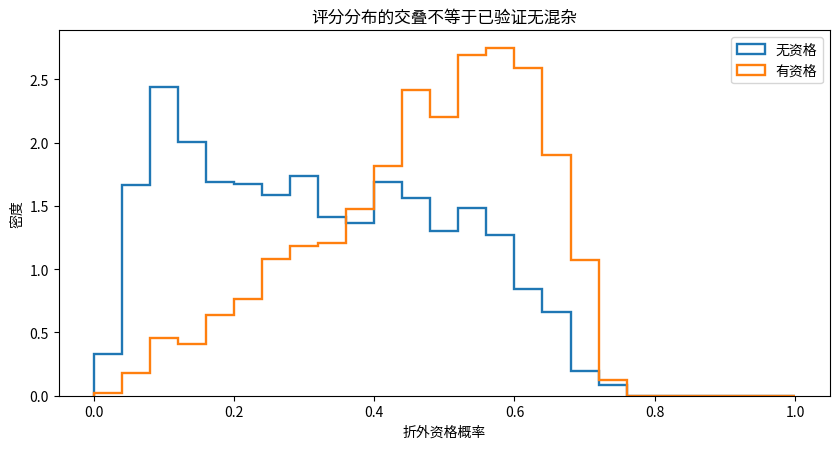

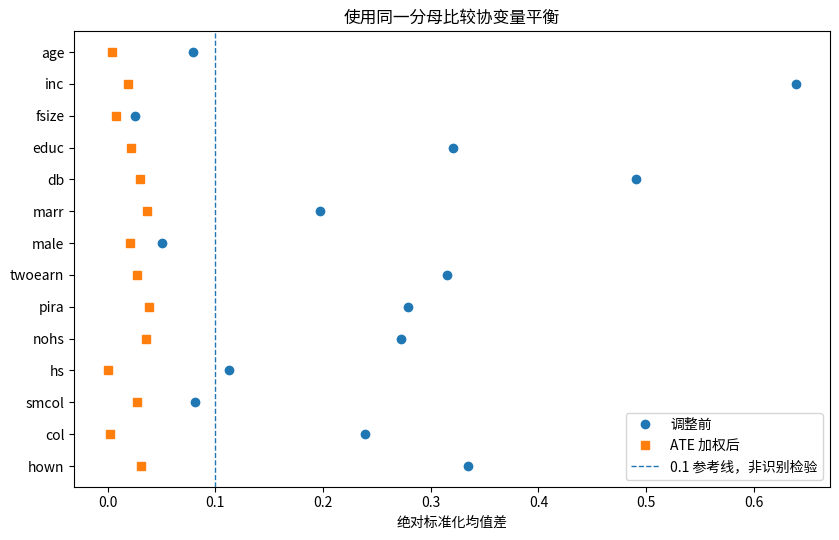

In [5]:
def nuisance_diagnostics(frame, eta):
    if not frame.index.equals(eta.index):
        raise ValueError("行号未对齐。")
    t, y, e = frame["T"].to_numpy(), frame.Y.to_numpy(), eta.e.to_numpy()
    factual = np.where(t == 1, eta.mu1, eta.mu0)
    out = {"事实结局RMSE": np.sqrt(mean_squared_error(y, factual)),
           "评分Brier": brier_score_loss(t, eta.raw_e), "最小评分": e.min(), "最大评分": e.max(),
           "截断行数": int(np.count_nonzero(e != eta.raw_e.to_numpy()))}
    for arm in [0, 1]:
        weights = 1/e[t == 1] if arm == 1 else 1/(1-e[t == 0])
        out[f"ESS_{arm}"] = weights.sum()**2/(weights @ weights)
        out[f"最大权重_{arm}"] = weights.max()
    return pd.Series(out)


def balance_table(frame, eta):
    if not frame.index.equals(eta.index):
        raise ValueError("行号未对齐。")
    t, e = frame["T"].to_numpy(), eta.e.to_numpy()
    x0, x1 = frame.loc[t == 0, X_COLS], frame.loc[t == 1, X_COLS]
    sd = np.sqrt((x0.var(ddof=0)+x1.var(ddof=0))/2)
    if (sd <= 0).any():
        raise ValueError("不能用零方差变量计算标准化均值差。")
    w0, w1 = 1/(1-e[t == 0]), 1/e[t == 1]
    raw_difference = x1.mean()-x0.mean()
    weighted_difference = (np.average(x1, axis=0, weights=w1)-np.average(x0, axis=0, weights=w0))
    return pd.DataFrame({"原始SMD": raw_difference/sd, "加权SMD": weighted_difference/sd})


display(nuisance_diagnostics(train, eta_train).round(4).to_frame("训练折外诊断"))
balance = balance_table(train, eta_train)
fig, ax = plt.subplots(figsize=(8.5, 4.6))
for t, label in [(0, "无资格"), (1, "有资格")]:
    ax.hist(eta_train.loc[train["T"] == t, "raw_e"], bins=np.linspace(0, 1, 26),
            density=True, histtype="step", linewidth=1.7, label=label)
ax.set(xlabel="折外资格概率", ylabel="密度", title="评分分布的交叠不等于已验证无混杂")
ax.legend()
fig.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(8.5, 5.5))
positions = np.arange(len(balance))
ax.plot(balance["原始SMD"].abs(), positions, "o", label="调整前")
ax.plot(balance["加权SMD"].abs(), positions, "s", label="ATE 加权后")
ax.axvline(0.1, linestyle="--", linewidth=1, label="0.1 参考线，非识别检验")
ax.set(yticks=positions, yticklabels=balance.index, xlabel="绝对标准化均值差", title="使用同一分母比较协变量平衡")
ax.invert_yaxis()
ax.legend()
fig.tight_layout()
plt.show()

### 5. 候选模型只保留五个

常数模型提供“只报告平均效应”的基线。T-Learner 直接相减两个结果预测；DR-Learner 用折外 $\widehat\Gamma$ 回归特征；R-Learner 最小化

$$
\sum_i\{Y_i-\widehat\ell_i-(T_i-\widehat e_i)f(X_i)\}^2,
\quad \widehat\ell_i=(1-\widehat e_i)\widehat\mu_{0i}+\widehat e_i\widehat\mu_{1i}.
$$

R 的样条规格是受限函数空间，其总体目标可能是重叠加权投影。这里将它作为一个候选预测函数，随后统一用 DR 损失在分析人群中评价，不能因它的训练损失较小就宣布总体 CATE 更准确。[2，第 15.1–15.2 节]

所有 CATE 模型都可使用全部训练样本；交叉拟合的是用于构造标签或残差的辅助模型，不是要求把最终效应模型也永远限制在某一折上。为了让 R 的求解看得见，下面直接构造残差乘样条的设计矩阵，不用小残差做除法。

In [6]:
def fit_candidates(frame, eta):
    g = dr_signal(frame, eta)
    fitted = {"常数": float(g.mean())}
    # T 路径的两个结果模型在整个训练集上重拟合，用于预测新样本。
    fitted["T-提升树"] = {f"mu{t}": outcome_model("boost").fit(
        frame.loc[frame["T"] == t, X_COLS], frame.loc[frame["T"] == t, "Y"]) for t in [0, 1]}
    fitted["DR-样条"] = make_pipeline(spline_features(), StandardScaler(), Ridge(alpha=20.0)).fit(frame[X_COLS], g)
    fitted["DR-提升树"] = HistGradientBoostingRegressor(max_iter=100, learning_rate=0.04,
        max_leaf_nodes=7, min_samples_leaf=100, l2_regularization=20,
        early_stopping=False, random_state=SEED_LEARNER).fit(frame[X_COLS], g)
    r_transform = make_pipeline(spline_features(), StandardScaler()).fit(frame[X_COLS])
    basis = np.column_stack([np.ones(len(frame)), r_transform.transform(frame[X_COLS])])
    b = frame["T"].to_numpy()-eta.e.to_numpy()
    a = frame.Y.to_numpy()-((1-eta.e)*eta.mu0+eta.e*eta.mu1).to_numpy()
    design = b[:, None]*basis
    # 不惩罚常数方向；其余样条系数采用固定岭惩罚。
    penalty = np.diag(np.r_[0.0, np.repeat(20.0, basis.shape[1]-1)])
    beta = np.linalg.solve(design.T @ design+penalty, design.T @ a)
    fitted["R-样条"] = (r_transform, beta)
    return fitted


def predict_candidates(fitted, frame):
    predictions = {}
    for name, model in fitted.items():
        if name == "常数":
            predictions[name] = np.full(len(frame), model)
        elif name == "T-提升树":
            predictions[name] = model["mu1"].predict(frame[X_COLS])-model["mu0"].predict(frame[X_COLS])
        elif name == "R-样条":
            transform, beta = model
            predictions[name] = np.column_stack([np.ones(len(frame)), transform.transform(frame[X_COLS])]) @ beta
        else:
            predictions[name] = model.predict(frame[X_COLS])
    result = pd.DataFrame(predictions, index=frame.index)
    if not np.isfinite(result.to_numpy()).all():
        raise ArithmeticError("候选模型产生非有限预测。")
    return result


candidates = fit_candidates(train, eta_train)
print("候选顺序：", list(candidates))
print(f"训练折外信号均值（常数模型）：{candidates['常数']:.4f} 千美元")
print("两个 DR 候选与 R 候选没有读取选择集或最终测试集。")

候选顺序： ['常数', 'T-提升树', 'DR-样条', 'DR-提升树', 'R-样条']
训练折外信号均值（常数模型）：8.0777 千美元
两个 DR 候选与 R 候选没有读取选择集或最终测试集。


### 6. 选择集负责评分，不负责给最终结论盖章

本篇的组合规则在运行前定为 Q-aggregation。令 $P_{ij}=f_j(X_i)$，在选择集上求

$$
\widehat w=\arg\min_{w_j\geq0,\,\sum_jw_j=1}
\left\{\frac1{n_s}\sum_i(\widehat\Gamma_i-P_iw)^2
+\sum_jw_j\frac1{n_s}\sum_i(\widehat\Gamma_i-P_{ij})^2\right\}.
$$

同时计算普通凸组合供比较，但不根据测试结果在两种组合间再挑一次。所有候选共享同一套选择集评分信号，辅助模型只用训练集拟合。[2，第 15.2 节]

优化前对预测与信号做相同的中心化、尺度缩放。由于权重和为一，两项损失都只乘同一个正常数，最优权重不变。它是数值处理，不是资产结局变成了标准差单位。

,估计,SE,下限,上限,p值,DR损失
T-提升树,227.1767,134.1704,-35.7924,490.1459,0.0904,9583.4408
DR-样条,18.1473,39.1119,-58.5106,94.8053,0.6427,9374.4114
DR-提升树,84.6525,81.0203,-74.1444,243.4493,0.2961,9440.9165
R-样条,26.1628,39.9781,-52.1928,104.5184,0.5128,9382.4268


,Q组合,凸组合
常数,0.739191,0.612976
T-提升树,0.000000,0.000000
DR-样条,0.260809,0.000000
DR-提升树,0.000000,0.090897
R-样条,0.000000,0.296127


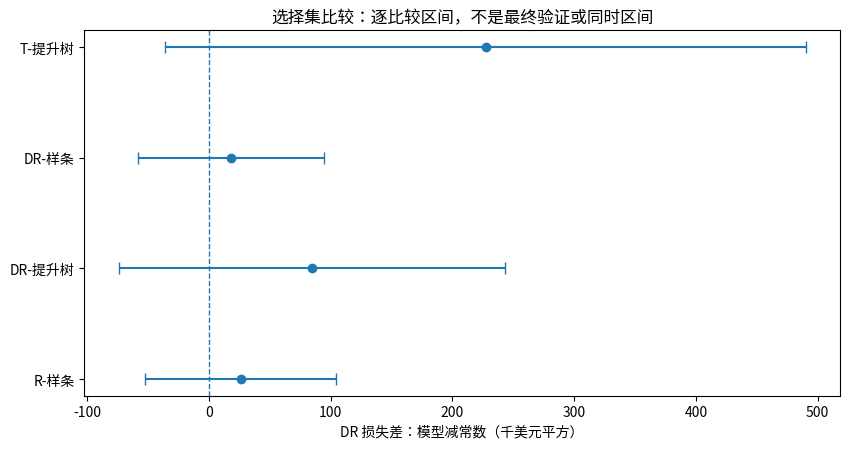

In [7]:
def mean_ci(values):
    v = vector(values)
    estimate = v.mean()
    se = v.std(ddof=1)/np.sqrt(len(v))
    return {"估计": estimate, "SE": se, "下限": estimate-Z_CRIT*se, "上限": estimate+Z_CRIT*se}


def paired_loss(gamma, prediction, reference):
    g, f, c = vector(gamma), vector(prediction), vector(reference)
    if not g.shape == f.shape == c.shape:
        raise ValueError("信号、模型与基线长度须相同。")
    row_difference = (f-c)*(f+c-2*g)
    result = mean_ci(row_difference)
    result["p值"] = 2*norm.sf(abs(result["估计"]/result["SE"])) if result["SE"] > 1e-12 else np.nan
    return result


def stack_weights(predictions, gamma, q_penalty=False):
    p, g = np.asarray(predictions, dtype=float), vector(gamma)
    if p.ndim != 2 or p.shape[0] != len(g) or p.shape[1] == 0 or not np.isfinite(p).all():
        raise ValueError("预测矩阵须与伪结局对齐。")
    center, scale = g.mean(), max(g.std(), 1e-8)
    p, g = (p-center)/scale, (g-center)/scale
    gram, cross = p.T @ p/len(g), p.T @ g/len(g)
    penalty = np.mean((p-g[:, None])**2, axis=0) if q_penalty else np.zeros(p.shape[1])
    def objective(w): return w @ gram @ w-2*cross @ w+penalty @ w
    def gradient(w): return 2*gram @ w-2*cross+penalty
    m = p.shape[1]
    result = minimize(objective, np.full(m, 1/m), jac=gradient, method="SLSQP",
        bounds=[(0., 1.)]*m,
        constraints={"type": "eq", "fun": lambda w: w.sum()-1, "jac": lambda w: np.ones(m)},
        options={"ftol": 1e-12, "maxiter": 1000})
    if not result.success or abs(result.x.sum()-1) > 1e-7 or result.x.min() < -1e-8:
        raise RuntimeError(f"组合优化失败：{result.message}")
    w = np.maximum(result.x, 0)
    w[w < 1e-10] = 0.0
    return w/w.sum()


pred_score = predict_candidates(candidates, score)
scoring_model = fit_nuisance(train)
eta_score = predict_nuisance(scoring_model, score)
gamma_score = dr_signal(score, eta_score)
score_table = pd.DataFrame({
    name: paired_loss(gamma_score, pred_score[name], pred_score["常数"])
    for name in pred_score if name != "常数"
}).T
score_table["DR损失"] = [np.mean((gamma_score-pred_score[name].to_numpy())**2) for name in score_table.index]
w_q = stack_weights(pred_score.to_numpy(), gamma_score, q_penalty=True)
w_convex = stack_weights(pred_score.to_numpy(), gamma_score, q_penalty=False)
weights = pd.DataFrame({"Q组合": w_q, "凸组合": w_convex}, index=pred_score.columns)
display(score_table.round(4))
display(weights.round(6))
selected_score = pred_score.to_numpy() @ w_q

fig, ax = plt.subplots(figsize=(8.6, 4.6))
pos = np.arange(len(score_table))
ax.errorbar(score_table["估计"], pos, xerr=Z_CRIT*score_table.SE, fmt="o", capsize=4)
ax.axvline(0, linestyle="--", linewidth=1)
ax.set(yticks=pos, yticklabels=score_table.index, xlabel="DR 损失差：模型减常数（千美元平方）",
       title="选择集比较：逐比较区间，不是最终验证或同时区间")
ax.invert_yaxis()
fig.tight_layout()
plt.show()

单次选择集上的最佳值有选择乐观性。表里的 p 值只是各个固定候选与常数的未校正比较，不作为挑出“显著有效模型”的程序。最终要回答的，是已经冻结的 Q 组合在新的测试集上是否优于常数。

### 7. 冻结模型、切点与解释范围

在用测试结局评价模型前，固定 Q 权重和四分位切点。图中每个点只是模型对选择集某条记录的预测，不是真实个人效应。按收入画图是描述模型输出，不是声称“增加收入会改变效应”，也不是保持其他变量不变后的收入因果效应。

若选出的模型为常数，分组和排序没有实际信息；代码会明确保留常数，不靠浮点误差创造异质性。

最终对象：Q组合；是否为常数： False
冻结的校准切点（千美元）： [6.5908 7.9559 9.6879]
收入、年龄等变量只用于预测资格效应，不能由重要性反推它们自己的因果作用。


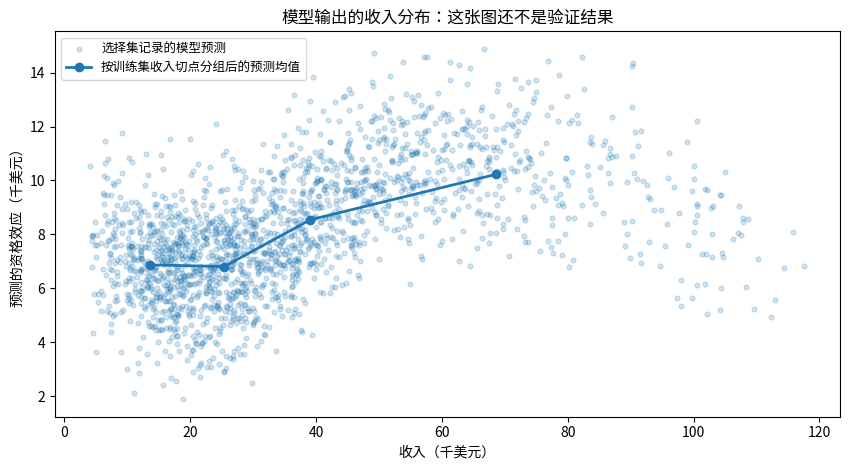

In [8]:
frozen_weights = w_q.copy()
frozen_names = tuple(pred_score.columns)
is_constant = np.ptp(selected_score) <= 1e-10
if is_constant:
    calibration_cuts = np.array([], dtype=float)
else:
    calibration_cuts = np.unique(np.quantile(selected_score, [0.25, 0.5, 0.75]))
    calibration_cuts = calibration_cuts[(calibration_cuts > selected_score.min()) &
                                       (calibration_cuts < selected_score.max())]
print("最终对象：Q组合；是否为常数：", is_constant)
print("冻结的校准切点（千美元）：", np.round(calibration_cuts, 4))
print("收入、年龄等变量只用于预测资格效应，不能由重要性反推它们自己的因果作用。")

fig, ax = plt.subplots(figsize=(8.6, 4.8))
ax.scatter(score.inc/MONEY_UNIT, selected_score, s=12, alpha=0.2, label="选择集记录的模型预测")
income_bins = pd.cut(score.inc, bins=np.r_[-np.inf, np.quantile(train.inc, [0.25, 0.5, 0.75]), np.inf])
profile = pd.DataFrame({"income": score.inc/MONEY_UNIT, "effect": selected_score, "bin": income_bins})
profile = profile.groupby("bin", observed=True).agg(income=("income", "mean"), effect=("effect", "mean"))
ax.plot(profile.income, profile.effect, "o-", linewidth=2, label="按训练集收入切点分组后的预测均值")
ax.set(xlabel="收入（千美元）", ylabel="预测的资格效应（千美元）",
       title="模型输出的收入分布：这张图还不是验证结果")
ax.legend(fontsize=9)
fig.tight_layout()
plt.show()

### 8. 在最终测试集上评价冻结模型

候选函数与组合权重保持不变。用于评价的辅助模型可在训练加选择集上重拟合，再预测测试集；这不会让测试结局进入模型训练。[2，第 15.3 节]

本篇只将 Q 组合与原先训练出的常数作主要性能比较。BLP、校准和 uplift 是次要诊断；各自的区间不构成跨全部诊断项目的统一多重检验校正。BLP 的斜率检验 $b=0$ 检查线性相关的异质性信号，联合检验 $(a,b)=(0,1)$ 检查线性校准；不拒绝校准原假设不等于证明校准正确。常数函数没有可估计的 BLP 斜率。

In [9]:
def blp_test(gamma, prediction):
    g, f = vector(gamma), vector(prediction)
    if g.shape != f.shape or f.std() < 1e-12:
        raise ValueError("预测须逐行对齐且具有非零变异，常数模型不能做 BLP 斜率检验。")
    x = np.column_stack([np.ones(len(f)), f])
    fitted = sm.OLS(g, x).fit(cov_type="HC1", use_t=False)
    a, b = fitted.params
    cov = np.asarray(fitted.cov_params())
    delta = fitted.params-np.array([0., 1.])
    wald = float(delta @ np.linalg.solve(cov, delta))
    return {"截距a": a, "斜率b": b, "SE_b": fitted.bse[1],
            "b下限": b-Z_CRIT*fitted.bse[1], "b上限": b+Z_CRIT*fitted.bse[1],
            "p_b=0": 2*norm.sf(abs(b/fitted.bse[1])),
            "p_线性校准": chi2.sf(wald, 2)}, fitted

# 冻结的最终模型与训练常数；没有利用测试集重新拟合 CATE。
pred_test = predict_candidates(candidates, test)
f_test = pred_test[list(frozen_names)].to_numpy() @ frozen_weights
development = pd.concat([train, score])
validation_model = fit_nuisance(development)
eta_test = predict_nuisance(validation_model, test)
gamma_test = dr_signal(test, eta_test)
primary_comparison = paired_loss(gamma_test, f_test, pred_test["常数"])
display(pd.DataFrame([primary_comparison], index=["Q组合减训练常数"]).round(5))
display(nuisance_diagnostics(test, eta_test).round(4).to_frame("最终评价辅助诊断"))

if np.std(f_test) > 1e-10:
    blp_result, blp_fit = blp_test(gamma_test, f_test)
    display(pd.DataFrame([blp_result], index=["冻结Q组合"]).round(5))
else:
    blp_result, blp_fit = None, None
    print("冻结模型为常数：不进行 BLP 斜率检验，不把缺少变异解释为检验通过。")

,估计,SE,下限,上限,p值
Q组合减训练常数,-8.2498,11.8159,-31.40853,14.90893,0.48506


,最终评价辅助诊断
事实结局RMSE,43.4332
评分Brier,0.1906
最小评分,0.0344
最大评分,0.7469
截断行数,0.0000
ESS_0,1122.6537
最大权重_0,3.9508
ESS_1,460.2440
最大权重_1,22.7860


,截距a,斜率b,SE_b,b下限,b上限,p_b=0,p_线性校准
冻结Q组合,-2.02895,1.27709,1.10567,-0.88998,3.44417,0.24807,0.96863


### 9. 同一组人的预测均值和 DR 组效应

用选择集切点给测试样本分组，分别计算模型预测均值与 DR 组效应。二者之差的标准误直接来自组内 $\widehat\Gamma_i-f(X_i)$，不是将两个相关均值当作独立量。

图上的纵向误差棒是各组效应的逐组 95% 区间，不是整条曲线的同时置信带，也不是每个人的效应范围。简单的分组平均校准误差仍有抽样噪声，不能与真实 CATE 的 MSE 混用。[2，第 15.3 节]

,组,n,n处理,平均预测,DR组效应,SE_组效应,校准差,SE_校准差,差下限,差上限
0,1,515,128,5.3612,5.1609,2.5576,-0.2003,2.5556,-5.2091,4.8085
1,2,437,145,7.3026,5.5083,2.6047,-1.7943,2.6042,-6.8984,3.3098
2,3,505,196,8.7658,9.0247,2.6145,0.2588,2.6143,-4.8652,5.3829
3,4,487,241,11.1588,13.6106,5.7942,2.4519,5.7963,-8.9086,13.8124


人数加权的分组平均校准误差： {'平均CAL1': 1.1379, '平均CAL2': 2.2578}


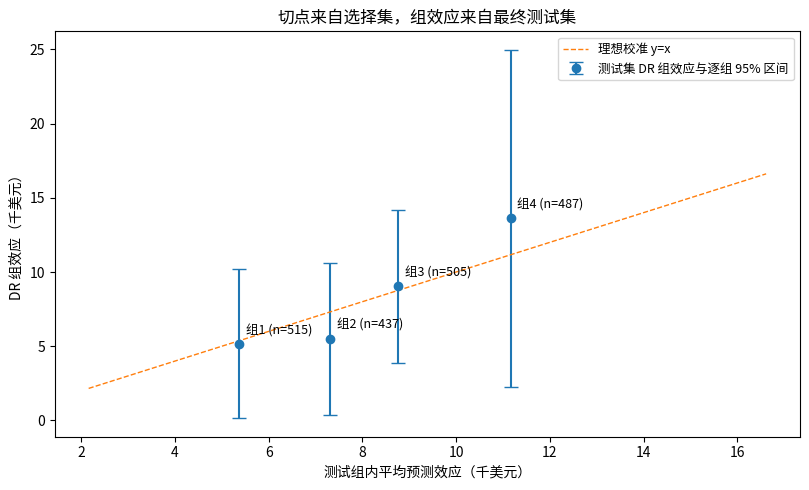

In [10]:
def calibration_table(gamma, prediction, cuts, treatment=None):
    g, f = vector(gamma), vector(prediction)
    cuts = np.asarray(cuts, float)
    if g.shape != f.shape or cuts.ndim != 1 or not np.isfinite(cuts).all() or np.any(np.diff(cuts) <= 0):
        raise ValueError("预测须对齐，有限切点须严格递增。")
    group = np.searchsorted(cuts, f, side="right")
    rows = []
    for k in range(len(cuts)+1):
        mask = group == k
        n_k = int(mask.sum())
        if n_k < 2:
            raise ValueError("某个冻结分组在测试集中不足 2 人，不能继续报告其区间。")
        gate = mean_ci(g[mask])
        gap = mean_ci(g[mask]-f[mask])
        rows.append([k+1, n_k, int(np.asarray(treatment)[mask].sum()) if treatment is not None else np.nan,
                     f[mask].mean(), gate["估计"], gate["SE"], gap["估计"], gap["SE"],
                     gap["下限"], gap["上限"]])
    table = pd.DataFrame(rows, columns=["组", "n", "n处理", "平均预测", "DR组效应", "SE_组效应",
                                        "校准差", "SE_校准差", "差下限", "差上限"])
    raw_cal1 = np.dot(table.n, np.abs(table.校准差))
    raw_cal2 = np.dot(table.n, table.校准差**2)
    metrics = {"CAL1人数总和": raw_cal1, "CAL2人数总和": raw_cal2,
               "平均CAL1": raw_cal1/len(g), "平均CAL2": raw_cal2/len(g)}
    return table, metrics, group

calibration, cal_metrics, test_groups = calibration_table(gamma_test, f_test, calibration_cuts, test["T"])
display(calibration.round(4))
print("人数加权的分组平均校准误差：", {k: round(float(v), 4) for k, v in cal_metrics.items() if k.startswith("平均")})

fig, ax = plt.subplots(figsize=(8.2, 5.0))
ax.errorbar(calibration["平均预测"], calibration["DR组效应"],
            yerr=Z_CRIT*calibration["SE_组效应"], fmt="o", capsize=5, label="测试集 DR 组效应与逐组 95% 区间")
for row in calibration.itertuples(index=False):
    ax.annotate(f"组{int(row[0])} (n={int(row[1])})", (row[3], row[4]), xytext=(5, 7),
                textcoords="offset points", fontsize=9)
limit = [min(calibration["平均预测"].min(), calibration["DR组效应"].min())-3,
         max(calibration["平均预测"].max(), calibration["DR组效应"].max())+3]
ax.plot(limit, limit, "--", linewidth=1, label="理想校准 y=x")
ax.set(xlabel="测试组内平均预测效应（千美元）", ylabel="DR 组效应（千美元）",
       title="切点来自选择集，组效应来自最终测试集")
ax.legend(fontsize=9)
fig.tight_layout()
plt.show()

### 10. 排在前面的人，平均效应是否更大？

对一条已经固定的优先规则 $h_q(X)\in[0,1]$，记实际覆盖比例为 $p_q=E[h_q(X)]$。并列分数时，$h_q$ 可表示边界上的随机入选概率，不读取结局决定谁入选。定义

$$
\operatorname{TOC}(q)=\frac{E[h_q(X)\Gamma]}{E[h_q(X)]}-E[\Gamma],\qquad
\operatorname{QINI}(q)=p_q\operatorname{TOC}(q).
$$

TOC 是优先组平均效应相对全体平均效应的增加；QINI 将它换到全体人口尺度。这里评价的是资格干预的排序，不是实际参与或增加缴费金额的效应。实际测试覆盖比例不必正好等于选择集定义的目标 $q$。[2，第 15.3 节]

给定已冻结规则，令 $\widehat a=\overline\Gamma$、$\widehat b_q=\overline{h_q\Gamma}/\overline h_q$，TOC 的影响值使用比值法则：

$$
\widehat\phi_{iq}=\frac{h_q(X_i)}{\widehat p_q}(\widehat\Gamma_i-\widehat b_q)
-(\widehat\Gamma_i-\widehat a).
$$

本实现与上一篇一致，计入测试集中随机分母的变化。原书该处展示的得分未展开这一项；这里采用上述直接推导的比值影响值，不把实现差异隐去。高斯同时区间仅覆盖预先规定的九条规则，不覆盖连续的整条曲线，也不计入重新估计总体排名分位数的误差。[2，第 15.3 节，Remark 15.3.2]

,目标q,冻结阈值,边界概率,实际比例,TOC,SE_TOC,同时下限,同时上限
0,0.1,11.2336,0.3,0.0972,-0.3738,9.5901,-25.0025,24.2548
1,0.2,10.0684,0.6,0.1996,5.0435,5.7820,-9.8054,19.8924
2,0.3,9.2807,0.9,0.3009,4.3151,3.5896,-4.9034,13.5336
3,0.4,8.5671,0.2,0.4028,3.3083,2.5121,-3.1431,9.7596
4,0.5,7.9559,0.5,0.5103,2.9166,1.7795,-1.6534,7.4865
5,0.6,7.4462,0.8,0.6008,2.5743,1.3737,-0.9536,6.1022
6,0.7,6.9002,0.1,0.6878,1.4818,1.0558,-1.2296,4.1933
7,0.8,6.1849,0.4,0.7978,0.7462,0.7911,-1.2855,2.7779
8,0.9,5.2773,0.7,0.8956,1.0206,0.3724,0.0643,1.9769


,曲线,"[0.1,0.9]离散面积",SE,下限,上限
0,TOC,2.0709,1.8897,-1.6327,5.7746
1,QINI,0.8726,0.6068,-0.3167,2.0619


九条固定规则的双侧95%同时临界值：2.5681


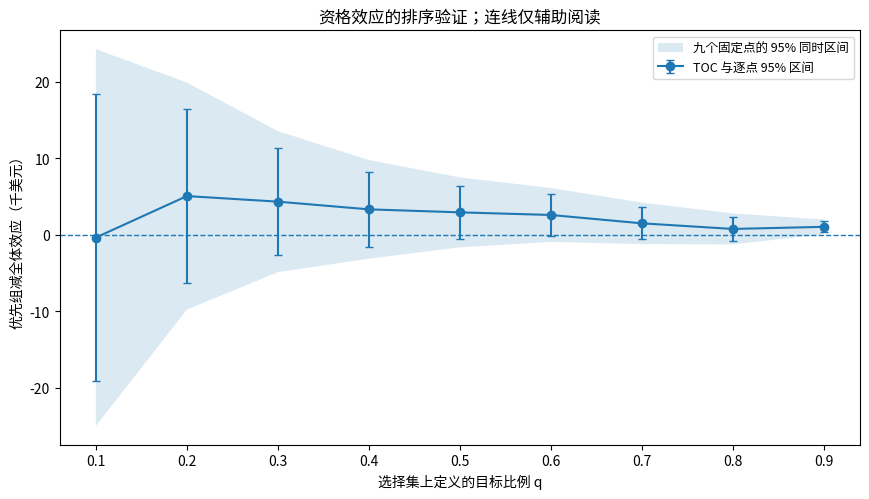

In [11]:
def threshold_policies(reference_scores, evaluation_scores, q_grid):
    """只从参考预测建立规则；评价样本不参与分位数或并列概率的估计。"""
    reference = vector(reference_scores, "阈值参考预测")
    evaluation = vector(evaluation_scores, "评价预测")
    q = np.asarray(q_grid, dtype=float)
    if q.ndim != 1 or not np.isfinite(q).all() or np.any((q <= 0) | (q > 1)):
        raise ValueError("目标比例须在 (0,1] 内。")
    sorted_ref = np.sort(reference)
    policies, records = [], []
    for fraction in q:
        if fraction == 1:
            policies.append(np.ones(len(evaluation)))
            records.append([fraction, -np.inf, 1.0, 1.0])
            continue
        # 用顺序统计量，不在线性插值后的空隙中制造“并列”。
        rank = max(0, min(len(reference)-1, int(np.ceil((1-fraction)*len(reference)))-1))
        cut = sorted_ref[rank]
        greater = np.mean(reference > cut)
        equal = np.mean(reference == cut)
        tie_probability = (fraction-greater)/equal
        if not -1e-10 <= tie_probability <= 1+1e-10:
            raise ArithmeticError("并列概率计算超出 [0,1]。")
        tie_probability = float(np.clip(tie_probability, 0, 1))
        h = (evaluation > cut).astype(float) + tie_probability*(evaluation == cut)
        policies.append(h)
        records.append([fraction, cut, tie_probability, h.mean()])
    return np.column_stack(policies), pd.DataFrame(records, columns=["目标q", "冻结阈值", "边界概率", "实际比例"])


def uplift_statistics(gamma, policies):
    """用随机分母的比值和协方差，计算固定规则的 TOC、QINI 与影响值。"""
    g = vector(gamma)
    h = np.asarray(policies, dtype=float)
    if h.ndim != 2 or h.shape[0] != len(g) or not np.isfinite(h).all() or np.any((h < 0) | (h > 1)):
        raise ValueError("策略矩阵须逐行对应伪结局，取值位于 [0,1]。")
    p = h.mean(axis=0)
    if np.any(p <= 0):
        raise ValueError("某条固定规则未选中任何测试样本，不能估计其组均值。")
    a = g.mean()
    gate = np.mean(h*g[:, None], axis=0)/p
    toc = gate-a
    qini = p*toc
    phi_toc = h/p*(g[:, None]-gate) - (g[:, None]-a)
    phi_qini = (h-p)*(g[:, None]-a)-qini
    assert np.allclose(phi_toc.mean(axis=0), 0, atol=1e-10)
    assert np.allclose(phi_qini.mean(axis=0), 0, atol=1e-10)
    # 协方差使用分母 n；与原书经验矩口径一致。
    cov_toc = phi_toc.T @ phi_toc/len(g)**2
    cov_qini = phi_qini.T @ phi_qini/len(g)**2
    return {"p": p, "ATE": a, "GATE": gate, "TOC": toc, "QINI": qini,
            "phi_TOC": phi_toc, "phi_QINI": phi_qini,
            "cov_TOC": cov_toc, "cov_QINI": cov_qini}


def simultaneous_critical(covariance, seed=SEED_BAND, draws=N_GAUSSIAN, alpha=0.05):
    cov = np.asarray(covariance, dtype=float)
    if cov.ndim != 2 or cov.shape[0] != cov.shape[1] or not np.isfinite(cov).all():
        raise ValueError("协方差须为有限方阵。")
    if draws < 100 or not 0 < alpha < 1 or not np.allclose(cov, cov.T):
        raise ValueError("模拟次数、显著性水平或协方差对称性不符。")
    if np.linalg.eigvalsh((cov+cov.T)/2).min() < -1e-9:
        raise ValueError("协方差不是半正定矩阵。")
    se = np.sqrt(np.maximum(np.diag(cov), 0))
    active = se > 1e-12
    if not active.any():
        return 0.0
    corr = cov[np.ix_(active, active)]/np.outer(se[active], se[active])
    values, vectors = np.linalg.eigh((corr+corr.T)/2)
    if values.min() < -1e-7:
        raise ValueError("协方差不是半正定矩阵。")
    root = vectors @ np.diag(np.sqrt(np.maximum(values, 0)))
    z = np.random.default_rng(seed).normal(size=(draws, len(values))) @ root.T
    return float(np.quantile(np.max(np.abs(z), axis=1), 1-alpha))


def trapezoid_weights(grid):
    q = np.asarray(grid, float)
    if q.ndim != 1 or len(q) < 2 or not np.isfinite(q).all() or np.any(np.diff(q) <= 0):
        raise ValueError("积分网格须至少有两个严格递增的有限点。")
    weight = np.zeros(len(q))
    weight[:-1] += np.diff(q)/2
    weight[1:] += np.diff(q)/2
    return weight

policies, policy_audit = threshold_policies(selected_score, f_test, Q_GRID)
uplift = uplift_statistics(gamma_test, policies)
critical_toc = simultaneous_critical(uplift["cov_TOC"])
se_toc = np.sqrt(np.diag(uplift["cov_TOC"]))
policy_audit["TOC"] = uplift["TOC"]
policy_audit["SE_TOC"] = se_toc
policy_audit["同时下限"] = uplift["TOC"]-critical_toc*se_toc
policy_audit["同时上限"] = uplift["TOC"]+critical_toc*se_toc
display(policy_audit.round(4))
area_weights = trapezoid_weights(Q_GRID)
area_rows = []
for metric in ["TOC", "QINI"]:
    estimate = float(area_weights @ uplift[metric])
    se = float(np.sqrt(area_weights @ uplift["cov_"+metric] @ area_weights))
    area_rows.append([metric, estimate, se, estimate-Z_CRIT*se, estimate+Z_CRIT*se])
area_table = pd.DataFrame(area_rows, columns=["曲线", "[0.1,0.9]离散面积", "SE", "下限", "上限"])
display(area_table.round(4))
print(f"九条固定规则的双侧95%同时临界值：{critical_toc:.4f}")

fig, ax = plt.subplots(figsize=(8.8, 5.1))
ax.fill_between(Q_GRID, uplift["TOC"]-critical_toc*se_toc, uplift["TOC"]+critical_toc*se_toc,
                alpha=0.16, label="九个固定点的 95% 同时区间")
ax.errorbar(Q_GRID, uplift["TOC"], yerr=Z_CRIT*se_toc, fmt="o-", capsize=3, label="TOC 与逐点 95% 区间")
ax.axhline(0, linestyle="--", linewidth=1)
ax.set(xlabel="选择集上定义的目标比例 q", ylabel="优先组减全体效应（千美元）",
       title="资格效应的排序验证；连线仅辅助阅读")
ax.legend(fontsize=9)
fig.tight_layout()
plt.show()

默认结果中，Q 组合主要给常数分配权重，其余给 DR 样条。最终测试的损失差区间跨过零，BLP 斜率的区间也较宽；这没有证实模型比常数更准确。九条固定规则的 TOC 同时区间中，$q=0.9$ 的下界略高于零，但离散面积区间仍跨零。这个局部排序信号与总体误差检验并不矛盾，不能把它扩展成“所有高预测组都稳定获益更多”。这些是本次固定设置的输出，修改参数后应重新阅读各表，而不是沿用本段数值判断。

前面模型选择已经结束，不根据这些结果换种子或更换学习器。

## 平均效应与稳健性分析

### 1. 在收入受限的全体样本上估计 ATE 和 ATT

现在回到平均效应。对主分析的 9,716 条记录重新做交叉拟合，两种辅助规格使用相同分折。ATT 不能直接平均资格组的 ATE 伪结局，而应使用

$$
\widehat\theta_{\mathrm{ATT}}=
\frac{\sum_i\left[T_i(Y_i-\widehat\mu_{0i})
-(1-T_i)\frac{\widehat e_i}{1-\widehat e_i}(Y_i-\widehat\mu_{0i})\right]}{\sum_iT_i}.
$$

记方括号内为 $A_i$、$\widehat p=n^{-1}\sum_iT_i$，其影响值为

$$
\widehat\phi_i^{\mathrm{ATT}}=
\frac{A_i-T_i\widehat\theta_{\mathrm{ATT}}}{\widehat p}.
$$

这同时计入资格组比例的随机性。ATE 与 ATT 对应不同人群，不把两个估计值的差异归结为“哪个方法更正确”。[1，第 13 章；2，第 9.4 节]

未调整均值差仅作描述性参照。标准化的预测差、IPW 也给出点估计帮助追踪 AIPW 的构成，但不为它们临时套用 AIPW 的标准误。

估计      SE      下限       上限
辅助模型 目标                                   
提升树  ATE   7.8677  0.9898  5.9278   9.8077
     ATT  10.4531  1.3528  7.8016  13.1047
加性样条 ATE   7.8582  0.9933  5.9113   9.8051
     ATT  10.6526  1.3256  8.0545  13.2508

,事实结局RMSE,评分Brier,最小评分,最大评分,截断行数,ESS_0,最大权重_0,ESS_1,最大权重_1
提升树,48.3640,0.1976,0.0248,0.7799,0.0,5495.4597,4.3585,2235.8394,36.8854
加性样条,48.1835,0.1982,0.0188,0.8267,0.0,5331.5287,5.2871,2401.1104,37.7543


未调整均值差（仅描述）     17.6933
结果标准化预测差         8.0118
资格侧平均残差纠偏       -0.2616
对照侧平均残差纠偏       -0.1176
AIPW_ATE         7.8677
IPW_Hajek点估计     8.1305
Name: 千美元, dtype: float64

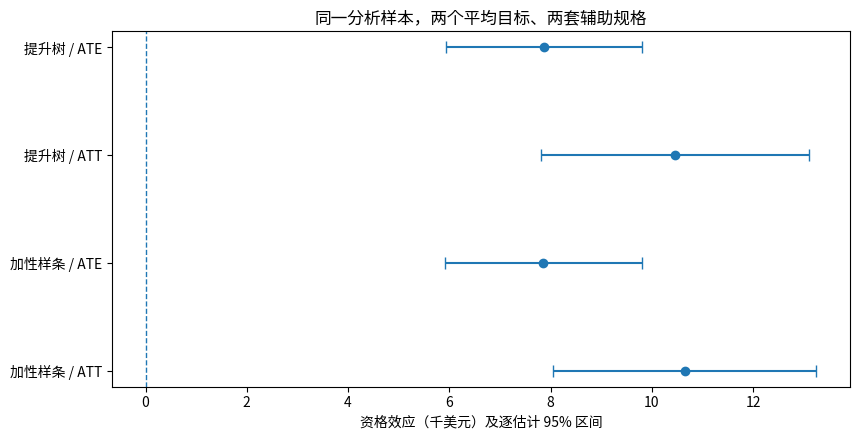

In [12]:
def average_effects(frame, eta):
    gamma = dr_signal(frame, eta)
    t, y, e = frame["T"].to_numpy(), frame.Y.to_numpy(), eta.e.to_numpy()
    p = t.mean()
    if not 0 < p < 1:
        raise ValueError("ATT 需要两组观察数据。")
    numerator = t*(y-eta.mu0.to_numpy())-(1-t)*e/(1-e)*(y-eta.mu0.to_numpy())
    ate, att = gamma.mean(), numerator.mean()/p
    phi_att = (numerator-t*att)/p
    records = []
    for name, estimate, influence in [("ATE", ate, gamma-ate), ("ATT", att, phi_att)]:
        se = np.sqrt(np.mean(influence**2)/len(frame))
        records.append([name, estimate, se, estimate-Z_CRIT*se, estimate+Z_CRIT*se])
    return pd.DataFrame(records, columns=["目标", "估计", "SE", "下限", "上限"]).set_index("目标"), gamma, phi_att


eta_full_boost, full_audit, full_splits = crossfit_nuisance(analysis, "boost")
eta_full_spline, _, _ = crossfit_nuisance(analysis, "spline", splits=full_splits)
full_results = {}
for name, eta in [("提升树", eta_full_boost), ("加性样条", eta_full_spline)]:
    table, _, _ = average_effects(analysis, eta)
    full_results[name] = table
average_table = pd.concat(full_results, names=["辅助模型", "目标"])
display(average_table.round(4))
display(pd.DataFrame({"提升树": nuisance_diagnostics(analysis, eta_full_boost),
                      "加性样条": nuisance_diagnostics(analysis, eta_full_spline)}).T.round(4))

eta = eta_full_boost
t, y, e = analysis["T"].to_numpy(), analysis.Y.to_numpy(), eta.e.to_numpy()
components = pd.Series({
    "未调整均值差（仅描述）": y[t == 1].mean()-y[t == 0].mean(),
    "结果标准化预测差": np.mean(eta.mu1-eta.mu0),
    "资格侧平均残差纠偏": np.mean(t*(y-eta.mu1)/e),
    "对照侧平均残差纠偏": np.mean((1-t)*(y-eta.mu0)/(1-e)),
    "AIPW_ATE": full_results["提升树"].loc["ATE", "估计"],
    "IPW_Hajek点估计": np.average(y[t == 1], weights=1/e[t == 1])
                      - np.average(y[t == 0], weights=1/(1-e[t == 0]))
}, name="千美元")
display(components.round(4))

fig, ax = plt.subplots(figsize=(8.7, 4.5))
pos = np.arange(len(average_table))
ax.errorbar(average_table["估计"], pos, xerr=Z_CRIT*average_table.SE, fmt="o", capsize=4)
ax.axvline(0, linestyle="--", linewidth=1)
ax.set(yticks=pos, yticklabels=[f"{a} / {b}" for a, b in average_table.index],
       xlabel="资格效应（千美元）及逐估计 95% 区间", title="同一分析样本，两个平均目标、两套辅助规格")
ax.invert_yaxis()
fig.tight_layout()
plt.show()

### 2. 不同样本范围，不是同一个 ATE

为核对样本范围，保留同样 14 个控制变量和提升树参数，在原始 9,915 条记录上重新执行一遍交叉拟合。下表的两个 ATE 平均人群不同，差值不是某一种方法的偏差；真实效应在任一人群中都未知。

原书表 9.3 的控制变量、学习器和分折与这里并不完全一致，所以只核对“未调整差值”和估计问题，不以追到原书某一个数字为调参目标。这里的收入限制是在开始前沿用来源的规则，不依据哪一行结果更显著来决定最终人群。

In [13]:
broad = raw[X_COLS].copy()
broad["T"] = raw.e401.astype(int)
broad["Y"] = raw.net_tfa/MONEY_UNIT
eta_broad, _, _ = crossfit_nuisance(broad, "boost")
broad_effects, _, _ = average_effects(broad, eta_broad)
range_table = pd.DataFrame([
    ["原始完整范围", len(broad), *broad_effects.loc["ATE", ["估计", "SE", "下限", "上限"]]],
    ["来源收入限制", len(analysis), *full_results["提升树"].loc["ATE", ["估计", "SE", "下限", "上限"]]]
], columns=["目标人群", "n", "ATE", "SE", "下限", "上限"])
display(range_table.round(4))

,目标人群,n,ATE,SE,下限,上限
0,原始完整范围,9915,8.1157,1.1523,5.8572,10.3742
1,来源收入限制,9716,7.8677,0.9898,5.9278,9.8077


### 3. 分折变了，结果变多少？

只在训练加选择集组成的固定开发样本上改变 10 个分折种子，不使用测试集做选择。观察数据、学习器、超参数和结局都不变，因此这不是 10 次独立重复抽样，也不能用 10 个系数的标准差替代抽样标准误。

每个点旁的区间来自该次交叉拟合得分；点与点之间的变化反映分折敏感性。输出全部种子，不挑其中最好看的一个。本篇不将简单平均这些结果冒充带有已校准方差的重复 DML 聚合算法。

,分折种子,ATE,SE,下限,上限
0,2100,7.2544,1.1694,4.9624,9.5464
1,2101,7.0811,1.1480,4.8310,9.3311
2,2102,7.4938,1.1473,5.2451,9.7425
3,2103,7.5623,1.1146,5.3777,9.7469
4,2104,7.0399,1.1460,4.7937,9.2861
5,2105,7.3096,1.1263,5.1021,9.5171
6,2106,7.3409,1.1600,5.0673,9.6145
7,2107,7.3352,1.1572,5.0672,9.6032
8,2108,7.1172,1.1647,4.8345,9.3999
9,2109,7.4556,1.1413,5.2187,9.6924


分折估计范围（千美元）： [7.0399 7.5623]
固定的是开发样本，不是重新抽取总体；范围不是置信区间。


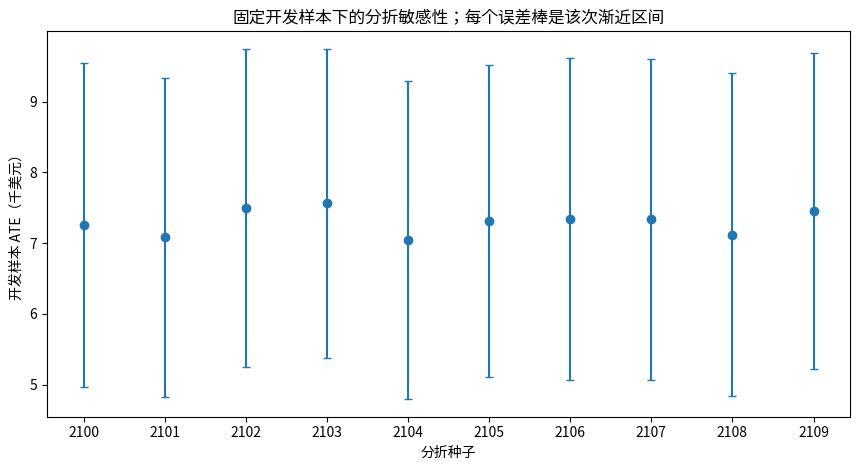

In [14]:
resplit_rows = []
for seed in SEEDS_RESPLIT:
    eta_dev, _, _ = crossfit_nuisance(development, "boost", seed=seed)
    estimate_dev, _, _ = average_effects(development, eta_dev)
    resplit_rows.append([seed, *estimate_dev.loc["ATE", ["估计", "SE", "下限", "上限"]]])
resplit_table = pd.DataFrame(resplit_rows, columns=["分折种子", "ATE", "SE", "下限", "上限"])
display(resplit_table.round(4))
print("分折估计范围（千美元）：", np.round([resplit_table.ATE.min(), resplit_table.ATE.max()], 4))
print("固定的是开发样本，不是重新抽取总体；范围不是置信区间。")

fig, ax = plt.subplots(figsize=(8.7, 4.8))
pos = np.arange(len(resplit_table))
ax.errorbar(pos, resplit_table.ATE, yerr=Z_CRIT*resplit_table.SE, fmt="o", capsize=3)
ax.set(xticks=pos, xticklabels=resplit_table["分折种子"], xlabel="分折种子",
       ylabel="开发样本 ATE（千美元）", title="固定开发样本下的分折敏感性；每个误差棒是该次渐近区间")
fig.tight_layout()
plt.show()

### 4. 截断评分，不等于解决了重叠问题

在同一组折外预测上，分别使用 0.005、0.01、0.025、0.05 的下界及对应上界重新计算 AIPW。这里只改变分母，不删除人、不重新拟合模型。原始 ATE 仍是目标，但若裁剪实际改变了概率且结果模型有误差，纠偏项未必再能正确消除偏差。

默认输出中，0.005 与 0.01 没有改变任何评分，因此估计完全相同；到 0.05 才改变较多记录。结果接近是这个数据与规格下的现象，不是截断无影响的一般结论。表中较窄的区间不代表较小的总误差。它没有包括裁剪造成的偏差，也没有包括未测混杂。关于评分裁剪和样本修剪的区别可回看第六份笔记。[1，第 20 章；2，第 9.3 节]

In [15]:
clip_rows = []
for bound in [0.005, 0.01, 0.025, 0.05]:
    changed = eta_full_boost.copy()
    changed["e"] = np.clip(changed.raw_e, bound, 1-bound)
    values, _, _ = average_effects(analysis, changed)
    diagnostics = nuisance_diagnostics(analysis, changed)
    clip_rows.append([bound, int((changed.e != changed.raw_e).sum()),
                      values.loc["ATE", "估计"], values.loc["ATE", "SE"],
                      diagnostics["ESS_0"], diagnostics["ESS_1"]])
clip_table = pd.DataFrame(clip_rows, columns=["评分下界", "改变行数", "ATE", "SE", "ESS_0", "ESS_1"])
display(clip_table.round(4))

,评分下界,改变行数,ATE,SE,ESS_0,ESS_1
0,0.005,0,7.8677,0.9898,5495.4597,2235.8394
1,0.010,0,7.8677,0.9898,5495.4597,2235.8394
2,0.025,1,7.8677,0.9898,5495.4598,2235.8394
3,0.050,279,7.8807,0.9894,5496.8634,2405.9025


### 5. 谁在支撑标准误？

长尾资产可能使少量记录主导估计不确定性。将 ATE 的平方影响值按大小排列，查看其累计占比。下面同时展示影响值最大的几行对应的评分与残差。

默认结果中，影响最大的约 1% 记录贡献超过七成的平方影响值，说明长尾对正态近似和区间稳定性值得关注。异方差稳健标准误允许方差不同，并不等于对极端记录不敏感。

这只是诊断，不因为某行影响大就删除它。按结局大小删除记录或把结局缩尾，会改变分析问题；仅删除固定得分中的某一项，也不等于删人后重新训练整个算法。

,T,Y,inc,e,mu0,mu1,Gamma,影响值,方差贡献比例
原始行号,,,,,,,,,
4674,0,1317.947,113199,0.5584,79.9441,89.9515,-2793.2144,-2801.0821,0.0848
8571,1,1134.098,39000,0.4340,18.5849,27.7104,2558.5687,2550.7009,0.0704
7345,1,-502.302,21240,0.2071,0.7796,8.0925,-2456.7746,-2464.6424,0.0657
7315,1,1536.798,81948,0.6024,67.6685,124.2180,2401.4837,2393.6159,0.0620
2779,0,1006.499,82251,0.5472,-1.3728,75.9939,-2148.3000,-2156.1677,0.0503
7463,1,1018.238,71358,0.6179,41.9971,41.8869,1579.8744,1572.0066,0.0267
6786,1,1098.624,55263,0.6738,58.8883,51.4603,1546.7443,1538.8765,0.0256
2957,0,1003.126,43272,0.3386,67.8979,103.8097,-1378.0061,-1385.8739,0.0208


影响最大的1%记录贡献了 71.40% 的平方影响值。


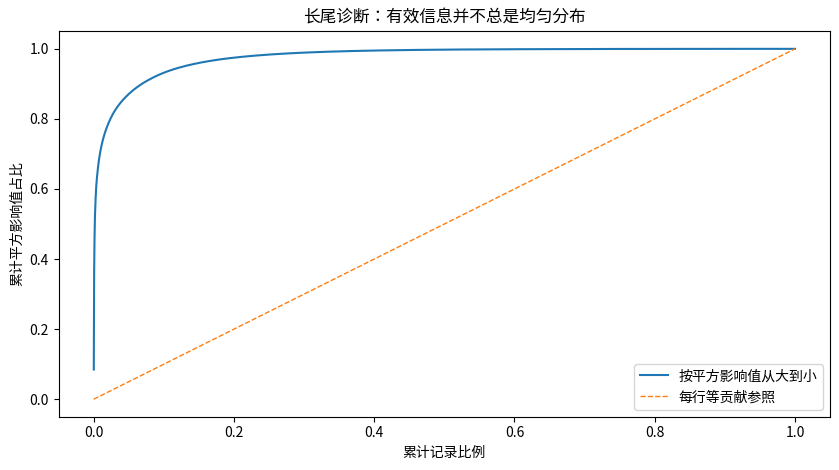

In [16]:
_, gamma_full, phi_att_full = average_effects(analysis, eta_full_boost)
phi_ate_full = gamma_full-gamma_full.mean()
order = np.argsort(phi_ate_full**2)[::-1]
squared_share = phi_ate_full[order]**2 / np.sum(phi_ate_full**2)
influence_table = analysis[["T", "Y", "inc"]].join(eta_full_boost[["e", "mu0", "mu1"]])
influence_table["Gamma"] = gamma_full
influence_table["影响值"] = phi_ate_full
influence_table["方差贡献比例"] = phi_ate_full**2/np.sum(phi_ate_full**2)
display(influence_table.iloc[order[:8]].round(4))
top_one_percent = max(1, int(np.ceil(0.01*len(analysis))))
print(f"影响最大的1%记录贡献了 {100*squared_share[:top_one_percent].sum():.2f}% 的平方影响值。")

fig, ax = plt.subplots(figsize=(8.5, 4.8))
fraction = np.arange(1, len(order)+1)/len(order)
ax.plot(fraction, np.cumsum(squared_share), label="按平方影响值从大到小")
ax.plot([0, 1], [0, 1], "--", linewidth=1, label="每行等贡献参照")
ax.set(xlabel="累计记录比例", ylabel="累计平方影响值占比", title="长尾诊断：有效信息并不总是均匀分布")
ax.legend()
fig.tight_layout()
plt.show()

## 结果应该怎样写？

先写目标人群、资格定义和资产单位，再报告平均效应与区间。异质性结论需区分：模型画出的变化、独立测试的损失改善、BLP 信号、组间校准以及排序价值。下面从实际输出生成一段记录，避免把原书数字或预想结论抄成这次结果。

这些数字仍不能验证条件可忽略性。两套辅助模型都只看到同一个控制集；它们的结论一致，也可能是遗漏了同一个混杂来源。均值差、折外 RMSE、平衡图和独立验证各有作用，但没有哪一项能替代研究设计。

In [17]:
main_ate = full_results["提升树"].loc["ATE"]
main_att = full_results["提升树"].loc["ATT"]
print(f"分析人群：收入位于 [{income_low:.2f}, {income_high:.2f}) 美元且收入为正的 {len(analysis)} 条记录。")
print(f"处理为401(k)资格，结局为净金融资产。提升树辅助模型的ATE为 {main_ate['估计']:.3f} 千美元，")
print(f"95%区间 [{main_ate['下限']:.3f}, {main_ate['上限']:.3f}]；ATT为 {main_att['估计']:.3f} 千美元。")
print(f"冻结Q组合相对训练常数的独立测试损失差为 {primary_comparison['估计']:.3f} 千美元平方，")
print(f"95%区间 [{primary_comparison['下限']:.3f}, {primary_comparison['上限']:.3f}]。")
if primary_comparison['上限'] < 0:
    print("该项比较支持Q组合具有较小的函数预测误差；它本身不证明无混杂。")
elif primary_comparison['下限'] > 0:
    print("该项比较支持Q组合的函数预测误差大于常数；不因曲线更复杂而保留相反结论。")
else:
    print("该项比较未能区分Q组合与常数的函数预测误差；不等于证明两者相同。")
if blp_result is not None:
    print(f"BLP斜率为 {blp_result['斜率b']:.3f}，检验b=0的p值为 {blp_result['p_b=0']:.4g}。")
print("上述区间均依赖识别与辅助估计条件；没有真实个人效应标签，也没有检验当代401(k)政策。")

分析人群：收入位于 [4080.00, 119058.24) 美元且收入为正的 9716 条记录。
处理为401(k)资格，结局为净金融资产。提升树辅助模型的ATE为 7.868 千美元，
95%区间 [5.928, 9.808]；ATT为 10.453 千美元。
冻结Q组合相对训练常数的独立测试损失差为 -8.250 千美元平方，
95%区间 [-31.409, 14.909]。
该项比较未能区分Q组合与常数的函数预测误差；不等于证明两者相同。
BLP斜率为 1.277，检验b=0的p值为 0.2481。
上述区间均依赖识别与辅助估计条件；没有真实个人效应标签，也没有检验当代401(k)政策。


## 练习

### 练习一：换成美元以后，哪些量改变？

把结局、两侧结果预测和 CATE 预测同时乘以 1,000，评分保持不变。核对 ATE、ATT 和标准误乘以 1,000，配对损失差及其标准误乘以 $10^6$，p 值不变。

这里固定已经训练好的函数，只检查估计与评价的尺度恒等式。它不声称任何软件在任意停止准则和惩罚设定下重新训练，都逐位返回完全等比例的模型。

In [18]:
dollars = analysis.copy()
dollars["Y"] *= MONEY_UNIT
eta_dollars = eta_full_boost.copy()
eta_dollars[["mu0", "mu1"]] *= MONEY_UNIT
scaled_effects, gamma_dollars, _ = average_effects(dollars, eta_dollars)
base_effects, _, _ = average_effects(analysis, eta_full_boost)
np.testing.assert_allclose(scaled_effects.to_numpy(), base_effects.to_numpy()*MONEY_UNIT, rtol=1e-12, atol=1e-9)
np.testing.assert_allclose(gamma_dollars, gamma_full*MONEY_UNIT, rtol=1e-12, atol=1e-8)
scaled_loss = paired_loss(gamma_test*MONEY_UNIT, f_test*MONEY_UNIT,
                          pred_test["常数"].to_numpy()*MONEY_UNIT)
for column in ["估计", "SE", "下限", "上限"]:
    np.testing.assert_allclose(scaled_loss[column], primary_comparison[column]*MONEY_UNIT**2, rtol=1e-10, atol=1e-5)
if np.isfinite(primary_comparison["p值"]):
    np.testing.assert_allclose(scaled_loss["p值"], primary_comparison["p值"], rtol=1e-10)
display(pd.concat({"千美元": base_effects, "美元": scaled_effects}, names=["单位", "目标"]).round(3))
print("单位核对通过：效应与标准误同倍变化，损失差按平方变化，检验结论不因单位改变。")

估计        SE        下限         上限
单位  目标                                           
千美元 ATE      7.868     0.990     5.928      9.808
    ATT     10.453     1.353     7.802     13.105
美元  ATE   7867.745   989.770  5927.832   9807.658
    ATT  10453.124  1352.848  7801.591  13104.658

单位核对通过：效应与标准误同倍变化，损失差按平方变化，检验结论不因单位改变。


### 练习二：把 `p401` 加入资格模型，会发生什么？

先不拟合任何新模型，只看资格与参与的列联表。实际参与需要先有资格，所以在参与者中找不到无资格组。用 `p401` 调整资格总效应，不仅可能控制处理后的变量，还会在这一层出现结构性的无重叠。

再区分两个问题：资格的 ATE 和“以资格为工具变量的参与 LATE”。后者需要额外的排除限制、单调性等条件，不是把 `T=e401` 改成 `T=p401` 后沿用同一解释。原书在第 13.2 节另行处理参与问题；本篇只核对它为何不是当前分析的同义改写，不在这里给出未经论证的参与效应。

In [19]:
participation_table = pd.crosstab(raw.loc[mask, "p401"], raw.loc[mask, "e401"])
participation_table = participation_table.reindex(index=[0, 1], columns=[0, 1], fill_value=0)
participation_table.index.name = "实际参与p401"
participation_table.columns.name = "资格e401"
display(participation_table)
conditional_e = participation_table[1]/participation_table.sum(axis=1)
display(conditional_e.to_frame("该层资格比例"))
assert participation_table.loc[1, 0] == 0
assert conditional_e.loc[1] == 1
print("在p401=1层，e401=0的样本数为0。把其估计概率截到0.99，也不会创造缺失的对照。")
print("资格总效应模型不加入p401；参与效应需要另外的识别设计与目标定义。")

资格e401,0,1
实际参与p401,,
0,6104,1077
1,0,2535


,该层资格比例
实际参与p401,
0,0.149979
1,1.000000


在p401=1层，e401=0的样本数为0。把其估计概率截到0.99，也不会创造缺失的对照。
资格总效应模型不加入p401；参与效应需要另外的识别设计与目标定义。


## 本篇小结

这个案例最重要的不是最后选中了哪一棵树，而是每一步保留了什么问题。样本筛选定义平均人群；变量角色定义处理与调整；折外预测用于正交估计；选择集决定组合；独立测试集评价冻结后的模型。最后，平均效应分析与异质性评价各自回到它们的目标，而不是把所有数字拼成一项“模型准确率”。

这里保留了净资产的负数和长尾，保留了每个分折种子的结果，也保留了可能不支持复杂模型的验证输出。将这个模板换成自己的研究数据时，应先重写处理、结局、时间顺序和识别论证，而不是只替换列名。

## 参考资料与实现口径

[1] Peng Ding. *A First Course in Causal Inference*. 上传版本为 arXiv:2305.18793v2，2023-10-03。第 10–13 章：识别、倾向评分、AIPW 与 ATT；第 20 章：重叠和样本限制。

[2] Victor Chernozhukov, Christian Hansen, Nathan Kallus, Martin Spindler, Vasilis Syrgkanis. *Applied Causal Inference Powered by ML and AI*. 使用上传文件的 2026-05-03、Version 0.1.2，而非按文件名认定为 2022 年版本。第 7.2、9.3–9.4、13.2、15.1–15.3 节。

[3] 配套数据与变量说明：[data/401k.csv](https://github.com/CausalAIBook/MetricsMLNotebooks/blob/main/data/401k.csv)、[data/401k.md](https://github.com/CausalAIBook/MetricsMLNotebooks/blob/main/data/401k.md)。来源为 R `hdm::pension`；本文件内嵌 CSV 的 Git blob 为 `cc6fa730232fcceac21a786fe017ad8ecf4d32d8`，SHA-256 在数据单元显示。快照恢复后逐字节匹配该 Git blob；不是从网页预览抽取的部分样本。

[4] 配套样本选择代码：[T/datasets.py](https://github.com/CausalAIBook/MetricsMLNotebooks/blob/main/T/datasets.py)，本次读取的 Git blob 为 `371af130e6b487277189f08bd1980edf1521a5c5`。采用该文件的收入限制与 14 个控制变量，未使用其无模拟时占位的 `true_cate` 返回值作为真实效应。

[5] scikit-learn 官方文档：[HistGradientBoostingRegressor](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.HistGradientBoostingRegressor.html)、[SplineTransformer](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.SplineTransformer.html)、[ColumnTransformer](https://scikit-learn.org/stable/modules/generated/sklearn.compose.ColumnTransformer.html)。学习器参数为本篇预先指定的教学规格，不是原书自动选择的参数。

[6] statsmodels 官方文档：[OLS 稳健协方差](https://www.statsmodels.org/stable/generated/statsmodels.regression.linear_model.OLSResults.get_robustcov_results.html)。BLP 使用 HC1 和正态参考分布。ATE／ATT 得分方差与 uplift 协方差使用经验矩分母 $n$；配对损失差和分组均值使用样本标准差分母 $n-1$，二者有限样本约定不混作逐位相同。

实现补充：原书分组 CAL 展示了按人数加权的和，本篇同时除以总人数得到平均；TOC 按随机分母的比值法则计算影响值；同时区间取高斯最大绝对值的 0.95 分位数，离散面积包含九个点之间的协方差。这些口径沿用上一篇的明确说明，不把缺少相应因子的展示公式直接复制到代码里。所有验证区间均以已训练模型和固定规则为条件，并依赖辅助估计误差足够小；全样本收入界限的估计误差、未测混杂、复杂调查设计和新时期外推均未被这些区间覆盖。